# Lab 3: Image Manipulations using OpenCV

ARTI 403 - Image Processing

Name: Mohammed Moayed Alquriniy  
ID: 2240007325

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cv2.imshow() opens the images in a new window, so I wrote a small function to show them inside the notebook using matplotlib. OpenCV loads color images as BGR, so they are converted to RGB before plotting.

In [2]:
def show(images, titles):
    plt.figure(figsize=(4 * len(images), 4))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        if len(images[i].shape) == 3:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

## Step 1: Read an image using OpenCV

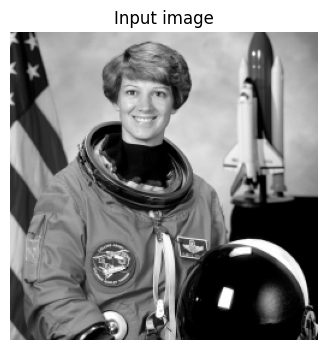

In [3]:
img = cv2.imread('../images/lena_gray_256.tif')
show([img], ['Input image'])

In [4]:
print(type(img))
print(img.shape)

<class 'numpy.ndarray'>
(256, 256, 3)


The image is read as a numpy array with shape (height, width, channels). lena_gray_256 is a grayscale image, but cv2.imread loads it with 3 channels by default (B, G and R have the same value in every pixel).

## Step 2: Load an image in grayscale

The image can be converted to grayscale while reading it by passing `cv2.IMREAD_GRAYSCALE`.

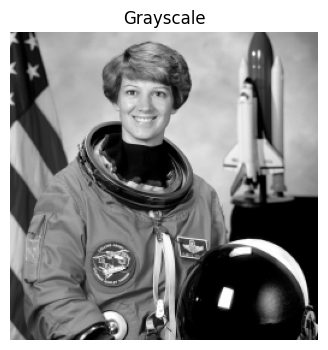

(256, 256)


In [5]:
gray_img = cv2.imread('../images/lena_gray_256.tif', cv2.IMREAD_GRAYSCALE)
show([gray_img], ['Grayscale'])
print(gray_img.shape)

Now the image has only one channel, so the shape is just (height, width).

## Step 3: Save an image

In [6]:
cv2.imwrite('../images/output.jpg', gray_img)

True

It returned True, so the grayscale image was saved as output.jpg in the images folder.

## Step 4: Convert an image to different color spaces

Converting an image that is already loaded to grayscale using `cv2.cvtColor`:

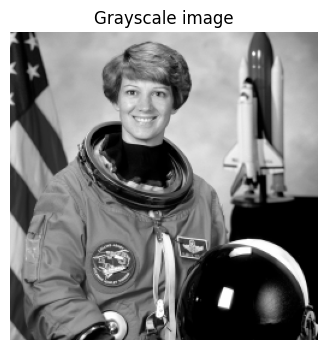

In [7]:
img = cv2.imread('../images/lena_gray_256.tif')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show([gray_img], ['Grayscale image'])

All the color conversion flags available in OpenCV:

In [8]:
flags = [x for x in dir(cv2) if x.startswith('COLOR_')]
print('Number of flags:', len(flags))
print(flags)

Number of flags: 374
['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA', 'COLOR_BAYER_GB2BGR_EA', 'COLOR_BAYER_GB2BGR_VNG', 'COLOR_BAYER_GB2GRAY', 'COLOR_BAYER_GB2RGB', 'COLOR_BAYER_GB2RGBA', 'COLOR_BAYER_GB2RGB_EA', 'COLOR_BAYER_GB2RGB_VNG', 'COLOR_BAYER_GBRG2BGR', 'COLOR_BAYER_GBRG2BGRA', 'COLOR_BAYER_GBRG2BGR_EA', 'COLOR_BAYER_GBRG2BGR_VNG', 'COLOR_BAYER_GBRG2GRAY', 'COLOR_BAYER_GBRG2RGB', 'COLOR_BAYER_GBRG2RGBA', 'COLOR_BAYER_GBRG2RGB_EA', 'COLOR_BAYER_GBRG2RGB_VNG', 'COLOR_BAYER_GR2BGR', 'COLOR_BAYER_GR2BGRA', 'COLOR_BAYER_GR2BGR_EA', 'COLOR_BAYER

Converting to YUV and showing each channel (Y: brightness, U: blue projection, V: red projection):

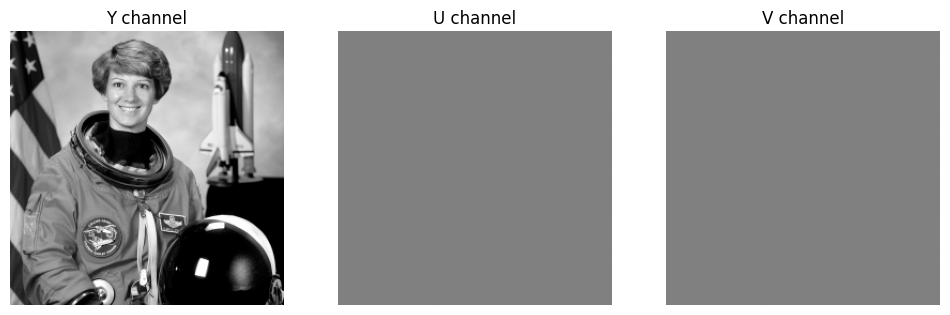

U values: [128]
V values: [128]


In [9]:
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
show([yuv_img[:, :, 0], yuv_img[:, :, 1], yuv_img[:, :, 2]], ['Y channel', 'U channel', 'V channel'])

print('U values:', np.unique(yuv_img[:, :, 1]))
print('V values:', np.unique(yuv_img[:, :, 2]))

The Y channel is the same as the grayscale image because it holds the brightness. U and V are flat gray and all their values are 128, because the image has no colors (B = G = R), so there is no blue or red information to store in them.

## Task 1: Geometric transformations

For the two tasks I used cameraman.tif.

### Increase the size of the image

Original size: (512, 512, 3)
New size: (768, 768, 3)


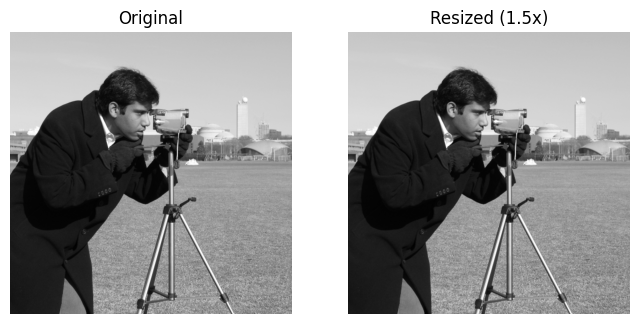

In [10]:
img = cv2.imread('../images/cameraman.tif')
bigger = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)

print('Original size:', img.shape)
print('New size:', bigger.shape)
show([img, bigger], ['Original', 'Resized (1.5x)'])

The width and height became 1.5 times the original. I used INTER_CUBIC because it gives a smoother result when making the image bigger. (Both images look the same size in the plot because matplotlib fits them in the figure, the printed shapes show the real size.)

### Rotate the image by 120 degrees

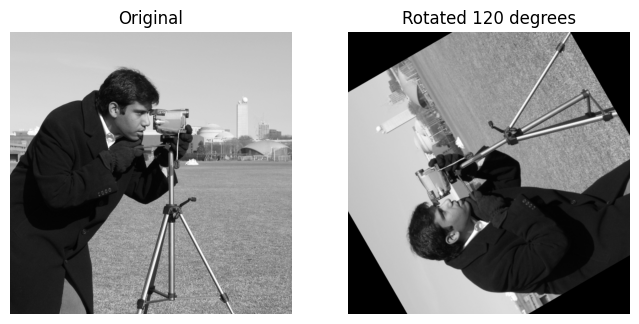

In [11]:
rows, cols = img.shape[:2]

M = cv2.getRotationMatrix2D((cols / 2, rows / 2), 120, 1)   # center, angle, scale
rotated = cv2.warpAffine(img, M, (cols, rows))

show([img, rotated], ['Original', 'Rotated 120 degrees'])

The image is rotated around its center. In OpenCV a positive angle means counter clockwise rotation. The corners are cut and filled with black because the output has the same size as the original image.

### Shear

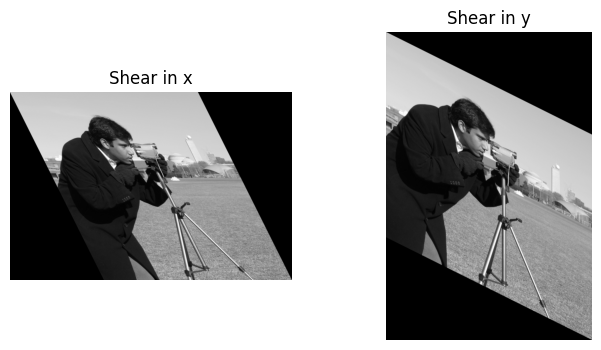

In [12]:
sh = 0.5

# shear in x direction
Mx = np.float32([[1, sh, 0],
                 [0, 1, 0]])
shear_x = cv2.warpAffine(img, Mx, (int(cols + sh * rows), rows))

# shear in y direction
My = np.float32([[1, 0, 0],
                 [sh, 1, 0]])
shear_y = cv2.warpAffine(img, My, (cols, int(rows + sh * cols)))

show([shear_x, shear_y], ['Shear in x', 'Shear in y'])

In the x shear each row is shifted to the right by (0.5 * y), so the lower rows move more and the image becomes slanted. In the y shear the columns are shifted down instead. I made the output image wider for the x shear and taller for the y shear so nothing gets cut.

## Task 2: Intensity transformations

Here I read the image in grayscale mode (one channel).

In [13]:
gray = cv2.imread('../images/cameraman.tif', cv2.IMREAD_GRAYSCALE)

### Negative image

$s = L - 1 - r$, where $L = 256$ for an 8-bit image.

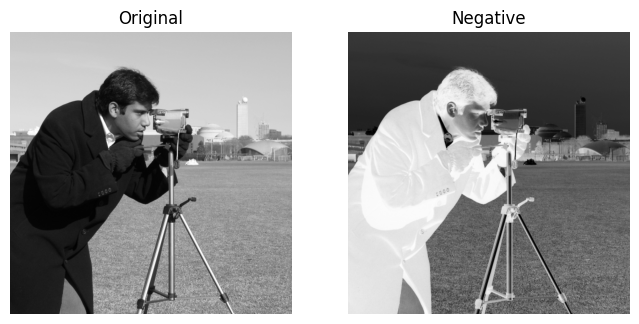

In [14]:
negative = 255 - gray
show([gray, negative], ['Original', 'Negative'])

Every pixel is inverted, the dark coat became white and the bright sky became dark.

### Log transformation

$s = c \cdot \log(1 + r)$

For the constant I used $c = 255 / \log(1 + r_{max})$, so the brightest pixel in the image goes to 255 and the result stays between 0 and 255.

c = 45.99


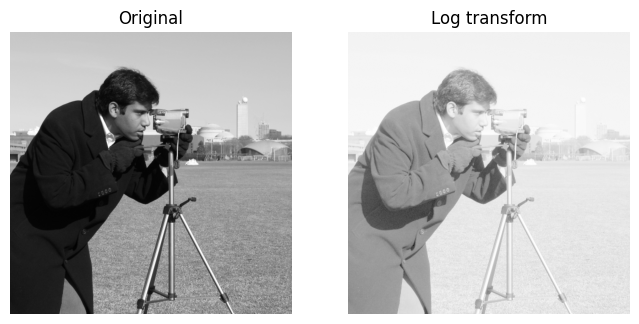

In [15]:
r = gray.astype(np.float64)   # float to avoid overflow when adding 1
c = 255 / np.log(1 + np.max(r))
print('c =', round(c, 2))

log_img = c * np.log(1 + r)
log_img = np.uint8(log_img)

show([gray, log_img], ['Original', 'Log transform'])

The log expands the dark values and compresses the bright ones. The coat and the camera became much brighter and their details are easier to see, but the bright areas like the sky and the grass look washed out.

### Power law (gamma)

$s = c \cdot r^{\gamma}$, where r is normalized to [0, 1] and c = 255.

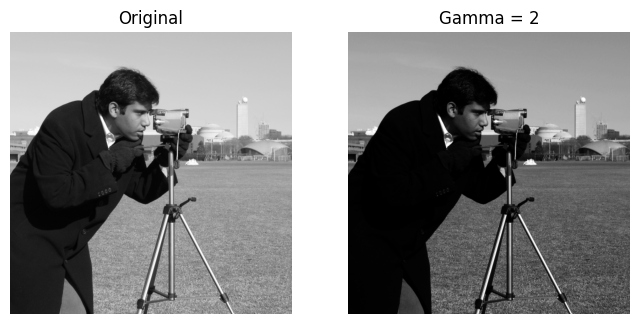

In [16]:
gamma = 2

gamma_img = 255 * (gray / 255) ** gamma
gamma_img = np.uint8(gamma_img)

show([gray, gamma_img], ['Original', 'Gamma = 2'])

I chose gamma = 2. With gamma > 1 the dark and middle gray levels are pushed down much more than the bright levels, so the differences between the bright values get bigger. This is clear in the background, the buildings are easier to see against the sky, so the contrast increased. The image also looks darker overall.